# Feature engineering

## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Configurar salidas de matplotlib
%matplotlib inline

## 2. Import data and transform

Leer csv

In [3]:
df = pd.read_csv('../data/clean/train_clean.csv')

In [4]:
df.head()

,Order Date,Ship Date,Ship Mode,Segment,City,State,Region,Category,Sub-Category,Sales
0,2015-01-03,2015-01-07,Standard Class,Consumer,Houston,Texas,Central,Office Supplies,Paper,16.448
1,2015-01-04,2015-01-08,Standard Class,Home Office,Naperville,Illinois,Central,Office Supplies,Binders,3.540
2,2015-01-04,2015-01-08,Standard Class,Home Office,Naperville,Illinois,Central,Office Supplies,Storage,272.736
3,2015-01-04,2015-01-08,Standard Class,Home Office,Naperville,Illinois,Central,Office Supplies,Labels,11.784
4,2015-01-05,2015-01-12,Standard Class,Consumer,Philadelphia,Pennsylvania,East,Office Supplies,Art,19.536


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    9800 non-null   str    
 1   Ship Date     9800 non-null   str    
 2   Ship Mode     9800 non-null   str    
 3   Segment       9800 non-null   str    
 4   City          9800 non-null   str    
 5   State         9800 non-null   str    
 6   Region        9800 non-null   str    
 7   Category      9800 non-null   str    
 8   Sub-Category  9800 non-null   str    
 9   Sales         9800 non-null   float64
dtypes: float64(1), str(9)
memory usage: 765.8 KB


Transformar las fechas.

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%Y-%m-%d')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%Y-%m-%d')

## 3. Formar fechas agrupadas por semanas

In [7]:
df.head()

,Order Date,Ship Date,Ship Mode,Segment,City,State,Region,Category,Sub-Category,Sales
0,2015-01-03,2015-01-07,Standard Class,Consumer,Houston,Texas,Central,Office Supplies,Paper,16.448
1,2015-01-04,2015-01-08,Standard Class,Home Office,Naperville,Illinois,Central,Office Supplies,Binders,3.540
2,2015-01-04,2015-01-08,Standard Class,Home Office,Naperville,Illinois,Central,Office Supplies,Storage,272.736
3,2015-01-04,2015-01-08,Standard Class,Home Office,Naperville,Illinois,Central,Office Supplies,Labels,11.784
4,2015-01-05,2015-01-12,Standard Class,Consumer,Philadelphia,Pennsylvania,East,Office Supplies,Art,19.536


Aquí vamos a agrupar las ventas de 1 semana completa, que es lo que vamos a intentar predecir.

In [8]:
df_week_sales = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
df_week_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


Tendencia semanal

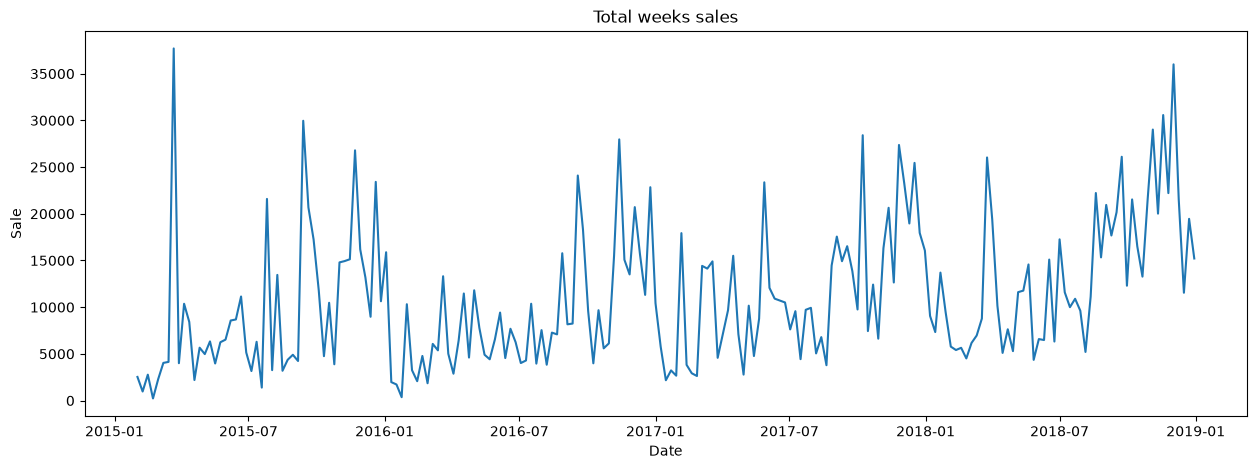

In [20]:
plt.figure(figsize=(15, 5))

plt.plot(
    df_week_sales['Order Date'],
    df_week_sales['Sales']
)

plt.title('Total weeks sales')
plt.xlabel('Date')
plt.ylabel('Sale')

plt.savefig('../outputs/model_figures/01_total_sales_by_weeks.png', bbox_inches='tight')
plt.show()

## 4. Control de continuidad

Para poder trabajar con los modelos, es necesario que no existan huecos en los datos (si por ejemplo hubo una semana que no se registró ningun día)

date_range nos va a dar la cantidad de semanas que hay desde tal fecha a tal fecha (con freq='W')

In [10]:
full_range = pd.date_range(start=df_week_sales['Order Date'].min(), 
                             end=df_week_sales['Order Date'].max(), 
                             freq='W')

print(f'Semanas esperadas: {len(full_range)}\nSemanas reales: {len(df_week_sales)}')

Semanas esperadas: 209
Semanas reales: 209


## 5. Lags and rolling

### 5.1 Lags

Crearemos features que indiquen las ventas anteriores, como cada registro es 1 semana, un lag de 1 es la semana anterior, y uno de 4 es hace 1 mes.

In [11]:
weeks_of_lag = ['1', '2', '3', '4']

for lag in weeks_of_lag:
    df_week_sales[f'Lag_{lag}'] = df_week_sales['Sales'].shift(int(lag))

df_week_sales.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Lag_4
0,2015-01-04,304.508,NaN,NaN,NaN,NaN
1,2015-01-11,4619.108,304.508,NaN,NaN,NaN
2,2015-01-18,4130.533,4619.108,304.508,NaN,NaN
3,2015-01-25,3092.544,4130.533,4619.108,304.508,NaN
4,2015-02-01,2527.914,3092.544,4130.533,4619.108,304.508


### 5.2 Rolling

Ahora pondremos el promedio de las 4 semanas anteriores.

Hacemos 1 shift para que la ventana del rolling no tome las ventas del mismo dia, si no que desde la semana anterior hacia atras.

In [12]:
df_week_sales['Rolling_4'] = df_week_sales['Sales'].shift(1).rolling(4).mean()
df_week_sales.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Lag_4,Rolling_4
0,2015-01-04,304.508,NaN,NaN,NaN,NaN,NaN
1,2015-01-11,4619.108,304.508,NaN,NaN,NaN,NaN
2,2015-01-18,4130.533,4619.108,304.508,NaN,NaN,NaN
3,2015-01-25,3092.544,4130.533,4619.108,304.508,NaN,NaN
4,2015-02-01,2527.914,3092.544,4130.533,4619.108,304.508,3036.67325


## 6. Nulls

Naturalmente se generaron filas con nulos, debido a que hay semanas que no tienen los suficientes datos anteriores.

In [13]:
df_week_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  209 non-null    datetime64[us]
 1   Sales       209 non-null    float64       
 2   Lag_1       208 non-null    float64       
 3   Lag_2       207 non-null    float64       
 4   Lag_3       206 non-null    float64       
 5   Lag_4       205 non-null    float64       
 6   Rolling_4   205 non-null    float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 11.6 KB


In [14]:
df_week_sales = df_week_sales.dropna(axis=0)

In [15]:
df_week_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 4 to 208
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  205 non-null    datetime64[us]
 1   Sales       205 non-null    float64       
 2   Lag_1       205 non-null    float64       
 3   Lag_2       205 non-null    float64       
 4   Lag_3       205 non-null    float64       
 5   Lag_4       205 non-null    float64       
 6   Rolling_4   205 non-null    float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 11.3 KB


## 7. Generar features de año y mes

In [16]:
df_week_sales.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Lag_4,Rolling_4
4,2015-02-01,2527.914,3092.544,4130.533,4619.108,304.508,3036.67325
5,2015-02-08,968.534,2527.914,3092.544,4130.533,4619.108,3592.52475
6,2015-02-15,2771.054,968.534,2527.914,3092.544,4130.533,2679.88125
7,2015-02-22,224.912,2771.054,968.534,2527.914,3092.544,2340.01150
8,2015-03-01,2289.643,224.912,2771.054,968.534,2527.914,1623.10350


In [17]:
df_week_sales['Month'] = df_week_sales['Order Date'].dt.month
df_week_sales['Year'] = df_week_sales['Order Date'].dt.year

In [18]:
df_week_sales.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Lag_4,Rolling_4,Month,Year
4,2015-02-01,2527.914,3092.544,4130.533,4619.108,304.508,3036.67325,2,2015
5,2015-02-08,968.534,2527.914,3092.544,4130.533,4619.108,3592.52475,2,2015
6,2015-02-15,2771.054,968.534,2527.914,3092.544,4130.533,2679.88125,2,2015
7,2015-02-22,224.912,2771.054,968.534,2527.914,3092.544,2340.01150,2,2015
8,2015-03-01,2289.643,224.912,2771.054,968.534,2527.914,1623.10350,3,2015


## 8. Guardar data para modelling

In [19]:
df_week_sales.to_csv('../data/processed/train_processed.csv', index=False)